In [1]:
from datetime import datetime, timedelta
import intake

cat = intake.open_catalog("https://tcodata.mpimet.mpg.de/catalog.yaml")
wxt = cat.BCO.surfacemet_wxt_v1.to_dask()
wxt["T"].sel(time=slice(datetime.now() - timedelta(days=30), datetime.now())).plot(figsize=(12, 4));

TypeError: No numeric data to plot.

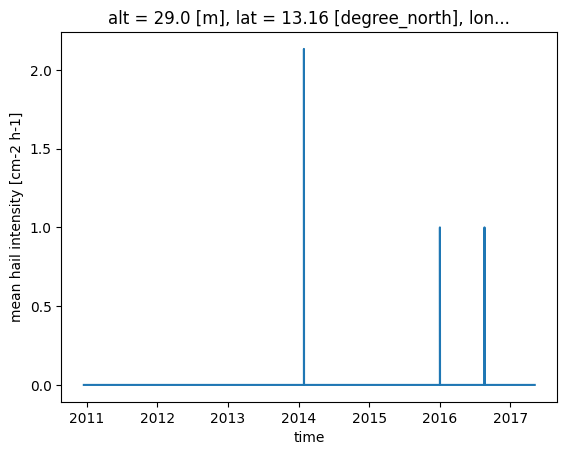

In [8]:
wxt["HI"].plot()

Text(0.5, 1.0, 'BCO SW radiation vs. clear-sky calculated')

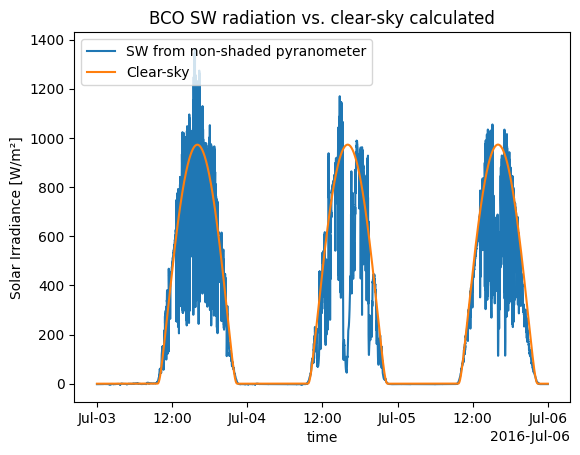

In [4]:
import intake
import matplotlib.pylab as plt
from pvlib import clearsky
from pvlib.location import Location
import pandas as pd
import xarray as xr

cat = intake.open_catalog("https://tcodata.mpimet.mpg.de/catalog.yaml")
ds_rad = cat.BCO.radiation_c2_v1.to_dask()

# select a few days of interest
subset = ds_rad.sel(time=slice("2016-07-03", "2016-07-05"))

# get clear sky calculated radiation for reference
lat, lon, alt = float(subset.lat), float(subset.lon), float(subset.alt)
bco = Location(lat, lon, 'UTC', alt, name = 'bco')
times = pd.to_datetime(subset.coords['time'].values)
cs = bco.get_clearsky(times).to_xarray().rename({'index': 'time'})
ds_cs = xr.merge([subset, cs])

# plot observed SW vs calculated clear-sky
ds_cs.SWD_global.plot(label='SW from non-shaded pyranometer')
ds_cs.ghi.plot(label='Clear-sky')
plt.legend(loc='upper left')
plt.ylabel('Solar Irradiance [W/m²]')
plt.title('BCO SW radiation vs. clear-sky calculated')